<a href="https://colab.research.google.com/github/nikhilvkth/325_Image_processing/blob/main/compression_stripes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image Shape: (512, 512)
Number of strips: 100
Strip shape: (512, 5)


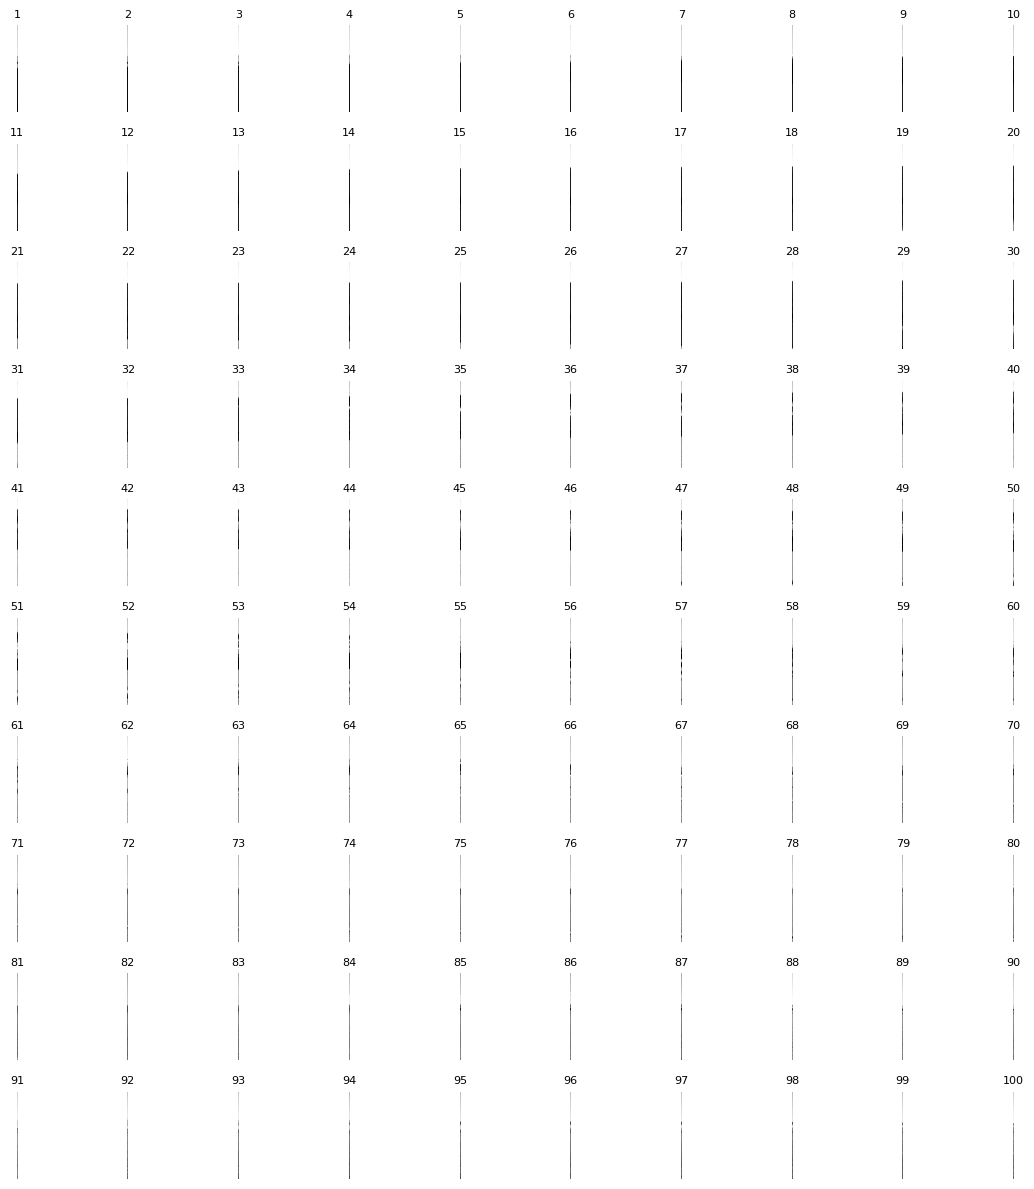

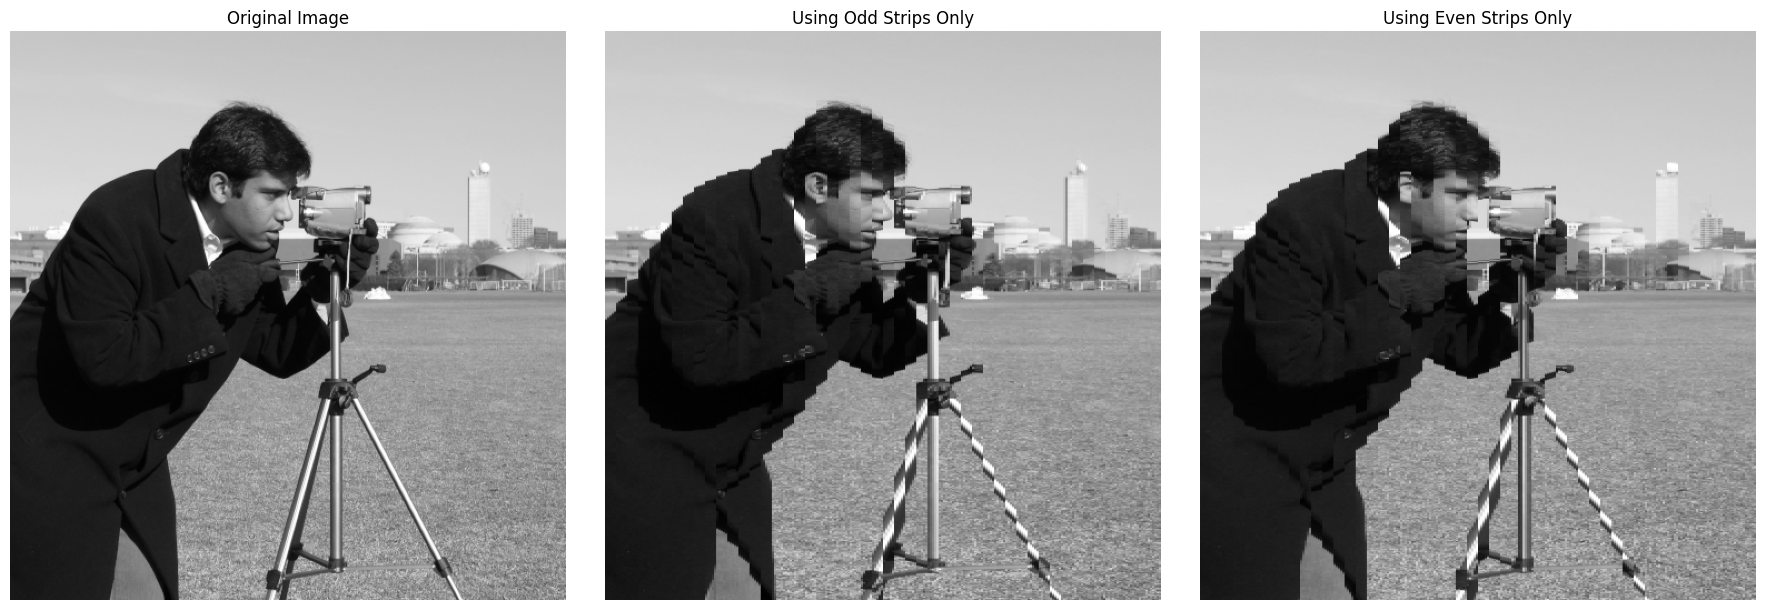

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load cameraman image
img = data.camera()

print("Original Image Shape:", img.shape)

# --------------------------------------------------
# Split image into 100 vertical strips
# --------------------------------------------------
num_strips = 100

h, w = img.shape

# Ensure width is divisible by 100
new_w = (w // num_strips) * num_strips
img = img[:, :new_w]

strip_width = new_w // num_strips

strips = []

for i in range(num_strips):
    start = i * strip_width
    end = (i + 1) * strip_width
    strips.append(img[:, start:end])

print("Number of strips:", len(strips))
print("Strip shape:", strips[0].shape)

# --------------------------------------------------
# Display all 100 strips
# --------------------------------------------------
fig, axes = plt.subplots(10, 10, figsize=(12,12))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(strips[i], cmap='gray')
    ax.set_title(str(i+1), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Select odd and even strips
# --------------------------------------------------
odd_strips = strips[0::2]    # 1st,3rd,5th,...
even_strips = strips[1::2]   # 2nd,4th,6th,...

# Create compressed representations
odd_image = np.hstack(odd_strips)
even_image = np.hstack(even_strips)

# --------------------------------------------------
# Reconstruct full-width images
# Duplicate each strip once to restore width
# --------------------------------------------------
odd_reconstructed = np.hstack(
    [np.repeat(s, 2, axis=1) for s in odd_strips]
)

even_reconstructed = np.hstack(
    [np.repeat(s, 2, axis=1) for s in even_strips]
)

# Ensure size matches original
odd_reconstructed = odd_reconstructed[:, :new_w]
even_reconstructed = even_reconstructed[:, :new_w]

# --------------------------------------------------
# Display results
# --------------------------------------------------
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(odd_reconstructed, cmap='gray')
plt.title('Using Odd Strips Only')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(even_reconstructed, cmap='gray')
plt.title('Using Even Strips Only')
plt.axis('off')

plt.tight_layout()
plt.show()